# Mesh Generation, Decomposition, and Visualization

This notebook explains the full mesh pipeline used in the project: mesh generation, decomposition, and visualization for numerical simulations.

In [1]:
%matplotlib widget
import numpy as np
from fem.mesh import Mesh

vertices = np.array([[0,0],[1,0],[1,1],[0,1]])
mesh = Mesh(vertices = vertices, options = 'qa0.01')

In [ ]:
from rich.console import Console
from rich.panel import Panel
console = Console()
console.print(Panel(mesh.info(), title="Mesh Summary", border_style="cyan"))

╭───────────────────────────────────────────────── Mesh Summary ──────────────────────────────────────────────────╮
│ Dimension: 2D                                                                                                   │
│ Domain: 0                                                                                                       │
│ Nodes: 88                                                                                                       │
│ Elements (triangles): 150                                                                                       │
│ Boundary nodes: 24                                                                                              │
│ Boundary elements: 52                                                                                           │
│ Measure (area): 1.0                                                                                             │
│ Mesh size (h): 0.25                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

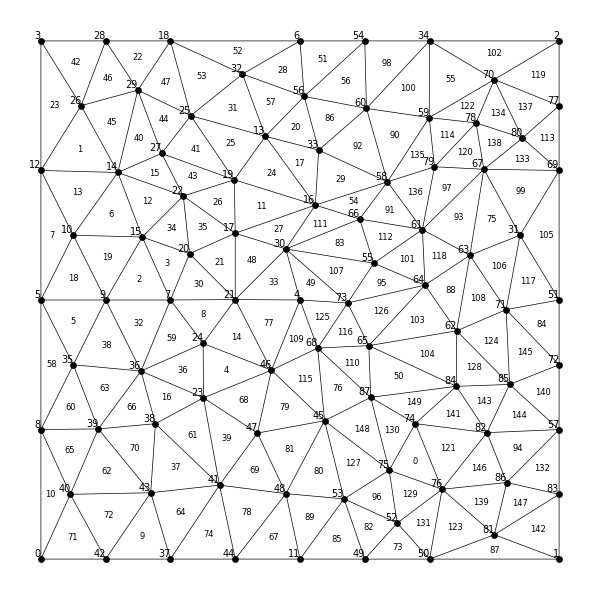

In [3]:
import visualization.visualize as visualize 
visualizer = visualize.MeshVisualizer(mesh)
visualizer.plot_mesh(figsize = (6, 6), dpi = 100, show_vertex_markers = True, show_node_numbers = True, show_element_numbers = True, axis_off = True)

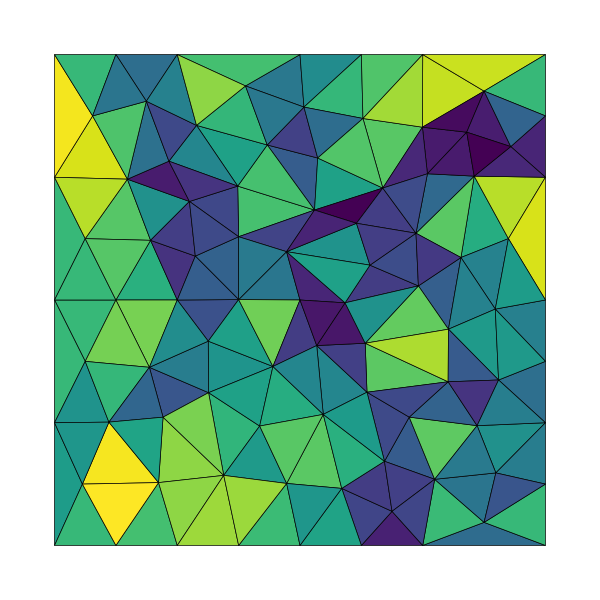

In [4]:
visualizer.plot_mesh(carray = visualizer.carray_areas(), figsize = (3, 3), dpi = 200, 
                    show_vertex_markers = False, show_node_numbers = False, show_element_numbers = False, show_color_bar = False, axis_off = True)

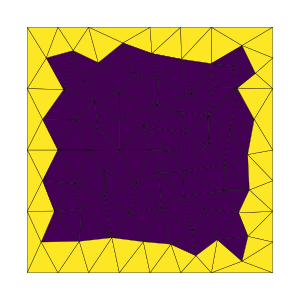

In [6]:
visualizer.plot_mesh(carray = visualizer.carray_boundary(), figsize = (3, 3), dpi = 100, 
                     show_vertex_markers = False, show_node_numbers = False, show_element_numbers = False, axis_off = True)

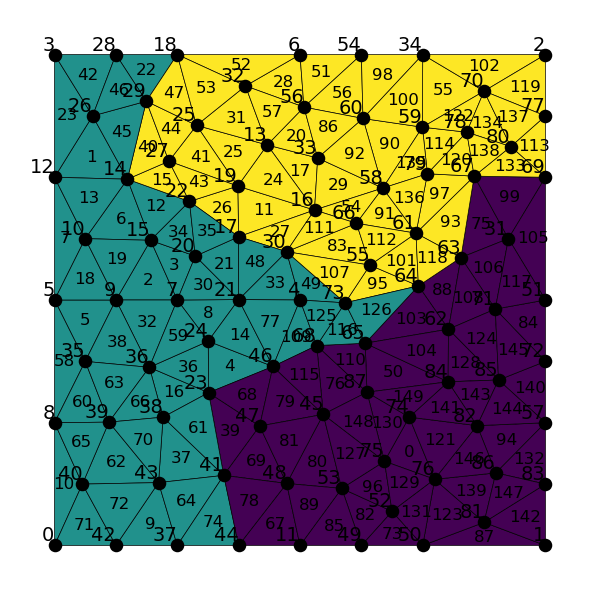

In [ ]:
subdomains, _, _, _, membership= mesh.decompose(n = 3, overlap = 1)
visualizer.plot_mesh(carray = membership, figsize = (3, 3), dpi = 200, show_vertex_markers = True, show_node_numbers = True, show_element_numbers = True, axis_off = True)

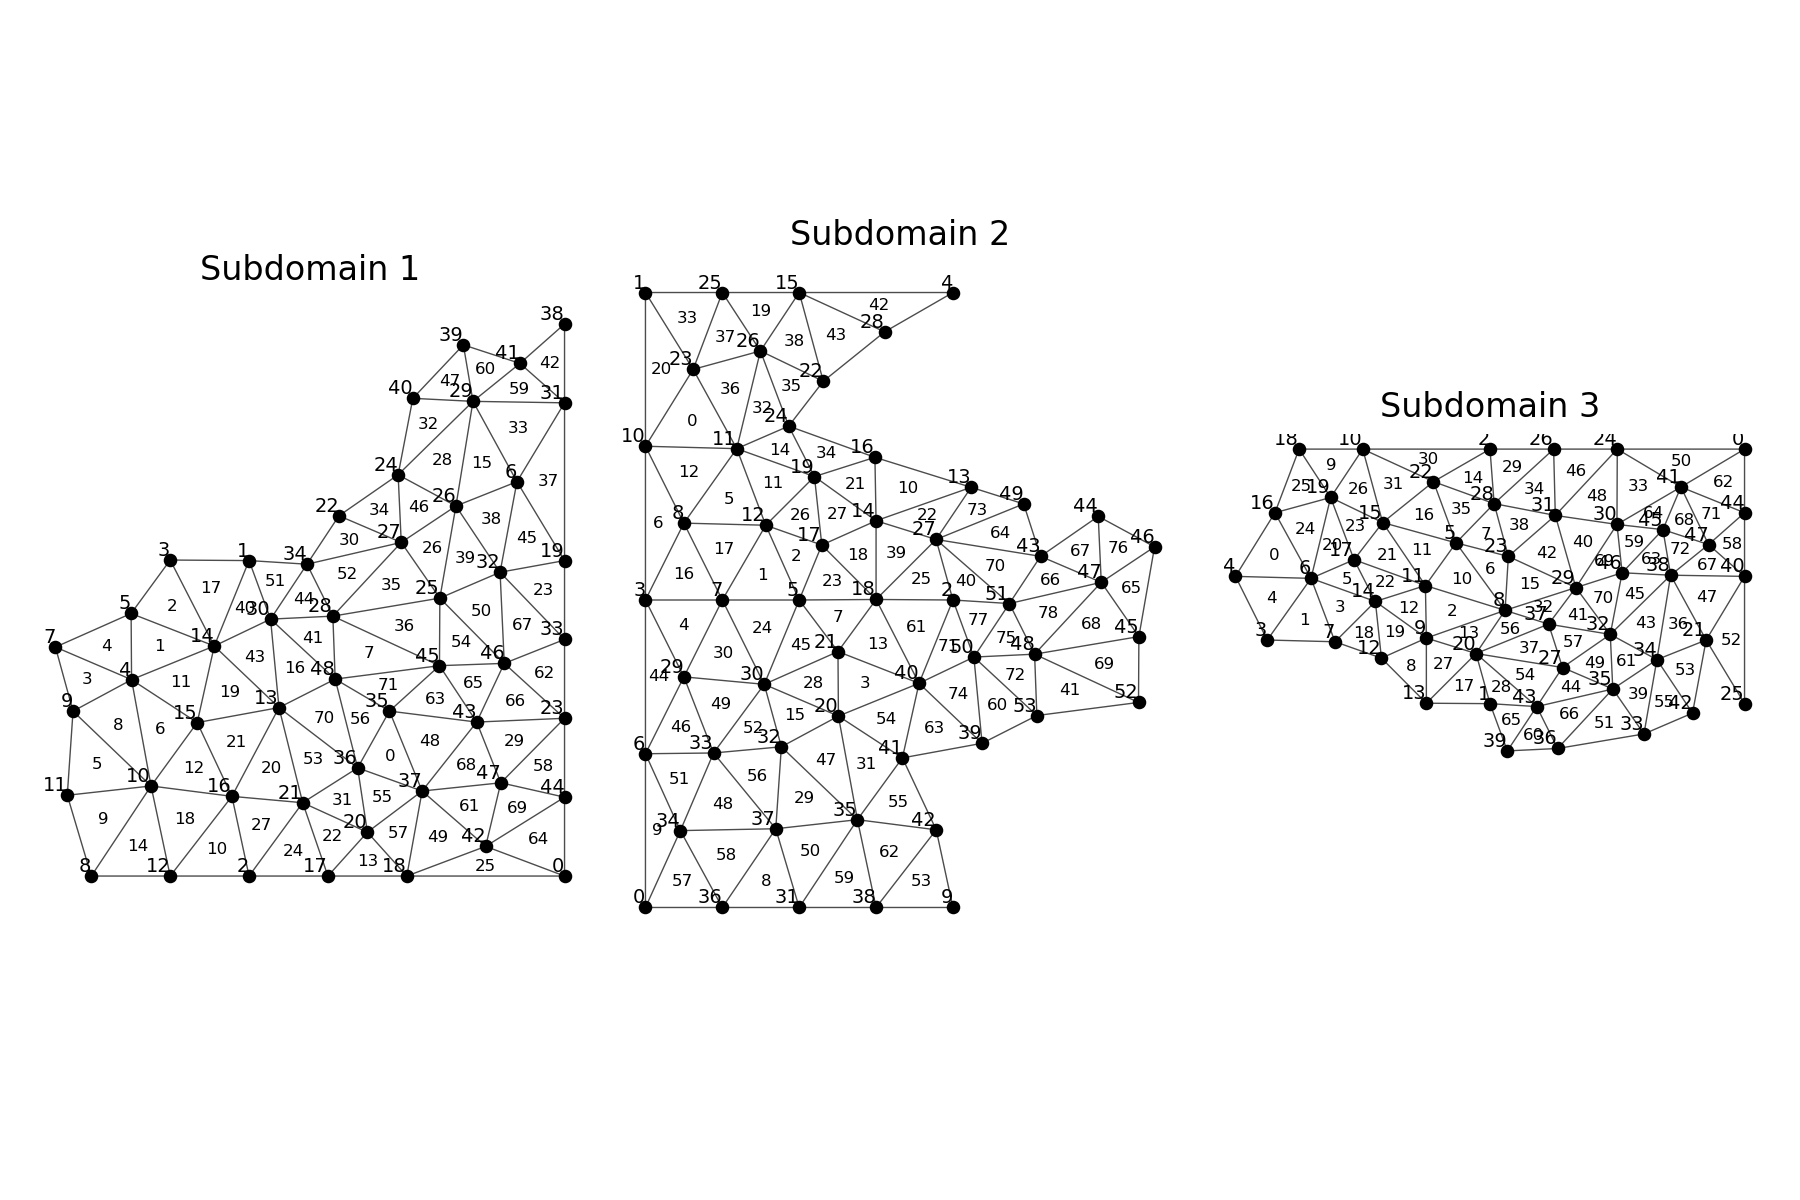

In [8]:
visualizer.plot_subdomains(subdomains = subdomains, membership = membership, figsize = (9, 6), dpi = 200, ncols = 3,
                           include_global_mesh = False, show_vertex_markers = True, show_node_numbers = True, show_element_numbers = True, axis_off = True)